# [실습] 의사결정나무와 앙상블

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

# 🌳 [실습] 의사결정나무와 앙상블 — 여러 모델을 모으면 강해진다

## — 같은 데이터, 더 강한 도구. 그런데 정말 더 강할까?

개념 노트북에서 의사결정나무부터 랜덤포레스트·부스팅까지 걸어왔습니다. 이제 그 도구들을 **지난 순서에서 쓰던 그 데이터**에 그대로 얹습니다. 같은 문제·같은 열·같은 분할이므로, 달라지는 것은 **모델뿐**입니다 — 그래서 비교가 정직해집니다.

> 🤖 **오늘의 AI 활용 규칙 — 손코딩 단계:** 코드는 손으로 씁니다. AI에게는 개념 *설명*만 요청하세요. (자세한 이유는 개념 노트북 Part 0)

## 📋 오늘의 미션

지난 순서에서 마케팅팀에 첫 답을 드렸습니다. 로지스틱 회귀로 구매 전환을 예측해 정확도 약 0.880을 냈습니다. 그런데 팀장이 이렇게 물어왔습니다.

> 🧑‍💼 "요즘 다들 쓴다는 **XGBoost** 같은 걸로 바꾸면 얼마나 더 좋아집니까? 그리고 **어떤 행동이 구매를 예고하는지**도 알려주실 수 있나요? 마케팅 예산을 어디에 쓸지 정해야 합니다."

두 질문 모두 오늘 배운 것으로 답할 수 있습니다. 성능 비교는 **4단 비교표**로, 두 번째 질문은 **피처 중요도**로 답합니다.

| 문제 | 내용 | 확인하는 힘 |
| --- | --- | --- |
| 1 | 단일 트리를 얹어 본다 | 학습-테스트 격차 읽기 |
| 2 | 가지치기로 격차를 줄인다 | 과적합 제어 |
| 3 | 숲과 부스팅 — 4단 비교표 | 베이스라인 대비 정직한 비교 |
| 4 | 피처 중요도를 비즈니스 언어로 | 숫자를 액션으로 번역 |
| 5 | 모델 카드 v2 완성 | 근거를 남기는 습관 (**제출물**) |

> ⚠️ **미리 알아두기:** 오늘도 지표는 **정확도**만 씁니다. 구매가 15.5%뿐인 데이터에서 정확도가 왜 위험한지는 이후 순서(평가 지표·불균형)에서 다룹니다. 오늘은 "모델을 바꾸면 무엇이 달라지나"에 집중하고, 그 한계를 **모델 카드에 적어 두는 것**까지가 과제입니다.

# ⚙️ 데이터 준비

지난 순서와 **똑같은 데이터·똑같은 열**을 씁니다. 저장소가 하나의 분석 포트폴리오로 쌓이도록, 순서마다 데이터를 갈아타지 않습니다.

| 데이터 | 내용 | 출처·라이선스 |
| --- | --- | --- |
| **Online Shoppers Purchasing Intention** | 온라인 스토어 방문 세션 12,330건 — 페이지 방문·체류·이탈률 등 18개 열, 타깃 `Revenue`(구매 여부) | [UCI 468](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset) · CC BY 4.0 |

`[C1]` 셀은 **최초 실행 시에만** 내려받아 `data/`에 저장합니다(지난 순서에서 받았다면 그 파일을 씁니다). 여전히 **수치형 10개 열만** 사용합니다 — 문자 열을 넣는 법은 피처·`Pipeline` 순서에서 배웁니다. 트리는 스케일링이 필요 없어 로지스틱에만 `StandardScaler`를 씁니다.

▶ 실행: [C1]

In [1]:
# ─────────────────────────────────────────────
# [C1] ◀ ⚙️ 데이터 준비
# 최초 1회 다운로드 → data/ 폴더에 저장 (이후 오프라인)
# ─────────────────────────────────────────────
import urllib.request, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def fetch_uci(url, zip_name, member):
    """UCI 정적 저장소의 zip을 내려받아 data/에 풀고, CSV 경로를 돌려줍니다."""
    csv_path = DATA_DIR / member
    if not csv_path.exists():
        zip_path = DATA_DIR / zip_name
        if not zip_path.exists():
            print(f"내려받는 중… {zip_name}")
            urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extract(member, DATA_DIR)
    return csv_path

shoppers = pd.read_csv(fetch_uci(
    "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip",
    "online_shoppers.zip", "online_shoppers_intention.csv"))

# 지난 순서와 동일한 수치형 10개 열 — 비교의 조건을 고정합니다
NUM_COLS = ["Administrative", "Administrative_Duration", "Informational",
            "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
            "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

print(f"쇼핑 세션 데이터: {shoppers.shape[0]:,}행 × {shoppers.shape[1]}열")
print(f"구매 전환율: {shoppers['Revenue'].mean():.4f}")
print("\n→ 준비 완료. 이제 여러분 차례입니다.")

내려받는 중… online_shoppers.zip
쇼핑 세션 데이터: 12,330행 × 18열
구매 전환율: 0.1547

→ 준비 완료. 이제 여러분 차례입니다.


# 문제 1. 단일 트리를 얹어 본다

먼저 비교의 기준선을 세웁니다. 지난 순서의 두 숫자 — **베이스라인(`DummyClassifier`)** 과 **로지스틱 회귀** — 를 다시 구하고, 그 옆에 **의사결정나무**를 나란히 놓습니다.

중요한 것이 하나 더 있습니다. 개념 노트북에서 배운 대로, 트리는 **학습 점수와 테스트 점수를 함께** 봐야 합니다. 테스트 점수만 보면 무슨 일이 벌어졌는지 알 수 없습니다.

```
[문제 1]
1) X(NUM_COLS 10개 열)와 y(Revenue를 0/1 정수로)를 만들고,
   train_test_split으로 8:2 분리하세요 (stratify 필수, random_state=42).
2) 세 모델을 학습시켜 학습 정확도 · 테스트 정확도 · 그 격차를 한 표로 출력하세요.
   ① DummyClassifier(strategy="most_frequent")
   ② LogisticRegression(max_iter=1000)  ← 스케일링 필요
   ③ DecisionTreeClassifier()           ← 기본 설정, 깊이 제한 없음
```

> 🤔 **예상해 볼까요?** 의사결정나무는 로지스틱 회귀보다 훨씬 유연한 모델입니다. 테스트 정확도가 **로지스틱(약 0.880)을 넘을까요?** 그리고 세 모델 중 학습-테스트 격차가 가장 큰 것은 무엇일까요?

▶ 실행: [C2]

In [2]:
# [C2] ◀ 문제 1. 단일 트리를 얹어 본다
# ⌨️ 문제 1 — 베이스라인 · 로지스틱 · 단일 트리를 나란히
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# 여기에 코드를 작성하세요 (X, y 준비 → 분리 → 세 모델 학습 → 학습·테스트·격차 표

X = shoppers[NUM_COLS]
y = shoppers["Revenue"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
dc = DummyClassifier(strategy="most_frequent")
dc.fit(X_train, y_train)
dc_train_score = dc.score(X_train, y_train)  # 학습 정확도
dc_test_score = dc.score(X_test, y_test)  # 테스트 정확도


lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
scaler = StandardScaler()
X_train_l = scaler.fit_transform(X_train)
X_test_l = scaler.transform(X_test)
lr.fit(X_train_l, y_train)
lr_train_score = lr.score(X_train_l, y_train)
lr_test_score = lr.score(X_test_l, y_test)

dtc = DecisionTreeClassifier() 
dtc.fit(X_train, y_train)
dtc_train_score = dtc.score(X_train, y_train)
dtc_test_score = dtc.score(X_test, y_test)

results = []
results.append({"model": "dummy", "train": dc_train_score, "test": dc_test_score})
results.append({"model": "logreg", "train": lr_train_score, "test": lr_test_score})
results.append({"model": "tree", "train": dtc_train_score, "test": dtc_test_score})

import pandas as pd
df = pd.DataFrame(results)
df["gap"] = df["train"] - df["test"]
df.round(3)

    model  train   test    gap
0   dummy  0.845  0.845  0.000
1  logreg  0.884  0.880  0.004
2    tree  1.000  0.842  0.158


<details>
<summary>(클릭) 💡 힌트</summary>

- `y`는 불리언이므로 `.astype(int)`로 0/1로 바꿉니다.
- 분류에서는 `stratify=y`를 잊지 마세요 — 양성이 15.5%뿐이라 분할 운에 크게 흔들립니다.
- 로지스틱만 스케일링이 필요합니다. `StandardScaler()`를 **학습 데이터로만** `fit`하고, 학습·테스트에 각각 `transform`합니다.
- 세 모델을 매번 똑같이 처리해야 하니 `dict` 목록에 결과를 모아 `pd.DataFrame(rows)`로 만들면 편합니다.
- 격차는 `학습 점수 − 테스트 점수`입니다.

</details>

> 🎯 **[C2] 예상과 맞았나요?** **기본 트리의 테스트 정확도 0.8423은 베이스라인 0.8451보다 낮습니다.** 이유는 학습 점수 **0.9998** — 9,864개 학습 세션을 거의 외웠습니다. 격차 **0.1575**가 그 증거입니다.
>
> 챙길 것 둘. ① **더 유연한 모델이 곧 더 좋은 모델은 아닙니다.** ② 학습 점수를 함께 보지 않았다면 "트리는 이 문제에 안 맞는다"고 잘못 결론 냈을 것입니다 — 진짜 문제는 모델 종류가 아니라 **제어되지 않은 복잡도**입니다.

# 문제 2. 가지치기로 격차를 줄인다

문제 1의 진단이 "복잡도가 통제되지 않았다"였으니, 처방은 **가지치기**입니다. 개념 노트북에서 본 손잡이 중 가장 직관적인 `max_depth`를 훑습니다.

```
[문제 2]
1) max_depth를 [2, 3, 5, 8, 12, None]으로 바꿔가며 트리를 학습시키고,
   각 깊이의 학습 정확도 · 테스트 정확도 · 격차를 표로 출력하세요.
2) 테스트 정확도가 가장 높은 깊이를 찾아 출력하세요.
3) 깊이에 따라 학습 점수와 테스트 점수가 어떻게 갈라지는지 선 그래프로 그리세요.
```

> 🤔 **예상해 볼까요?** 깊이를 2에서 `None`까지 늘리면 **학습 점수**는 어떻게 움직일까요? 그리고 **테스트 점수**는요? 두 곡선이 같은 모양일까요?

▶ 실행: [C3]

  depth  train   test    gap
0     2  0.892  0.886  0.006
1     3  0.893  0.883  0.010
2     5  0.905  0.894  0.011
3     8  0.925  0.888  0.037
4    12  0.957  0.875  0.083
5  None  1.000  0.842  0.158
테스트 정확도가 가장 높은 깊이 = 5, 테스트 정확도 = 0.894


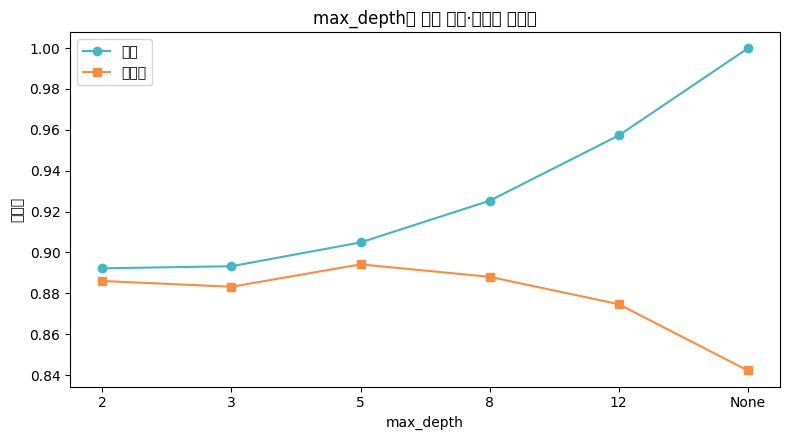

In [3]:
# [C3] ◀ 문제 2. 가지치기로 격차를 줄인다
# ⌨️ 문제 2 — max_depth를 훑어 과적합을 통제하기

# 여기에 코드를 작성하세요 (깊이별 학습·테스트·격차 표 → 최고 깊이 → 선 그래프)

import warnings
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

font_path = Path("C:/Windows/Fonts/malgun.ttf")
if font_path.exists():
    fm.fontManager.addfont(str(font_path))
    plt.rcParams["font.family"] = fm.FontProperties(fname=str(font_path)).get_name()

plt.rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore", category=UserWarning, message=r"Glyph .* missing from font.*")

depths = [2, 3, 5, 8, 12, None]
tr, te, results = [], [], []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(X_train, y_train)
    tr_score = m.score(X_train, y_train); te_score = m.score(X_test, y_test)
    tr.append(tr_score); te.append(te_score)
    results.append({"depth": "None" if d is None else d, "train": tr_score, "test": te_score, "gap": tr_score - te_score})

df = pd.DataFrame(results)
print(df.round(3))

best = depths[int(np.argmax(te))]
print(f"테스트 정확도가 가장 높은 깊이 = {best}, 테스트 정확도 = {max(te):.3f}")

xs = range(len(depths))
plt.figure(figsize=(8, 4.5))
plt.plot(xs, tr, "o-", label="학습", color="#41b6c4")
plt.plot(xs, te, "s-", label="테스트", color="#fd8d3c")
plt.xticks(xs, [str(d) for d in depths])
plt.xlabel("max_depth"); plt.ylabel("정확도")
plt.title("max_depth에 따른 학습·테스트 정확도")
plt.legend(); plt.tight_layout(); plt.show()

<details>
<summary>(클릭) 💡 힌트</summary>

- `for depth in [2, 3, 5, 8, 12, None]:` 으로 돌리고 `DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)`를 매번 새로 만듭니다.
- `None`은 문자로 바꿔야 표에 깔끔하게 들어갑니다 — `str(depth)`.
- 최고 지점은 `DataFrame`의 `.idxmax()`로 찾습니다: `표.loc[표["테스트"].idxmax()]`.
- 그래프의 가로축에 `None`을 그리기는 어렵습니다. `None`을 큰 수(예: 20)로 대체해 그리거나, `range(len(depths))`를 축으로 쓰고 `plt.xticks`로 이름을 붙이세요.

</details>

> 🎯 **[C3] 예상과 맞았나요?** 학습 점수는 깊이에 따라 **단조롭게 오르지만**(0.8922 → 0.9998), 테스트 점수는 깊이 5에서 **0.8942**로 정점을 찍고 내려갑니다.
>
> **`max_depth=5` 한 줄로 0.8423 → 0.8942, 즉 +0.0519입니다.** 데이터를 더 모으지도 모델을 바꾸지도 않고, 손잡이 하나를 돌렸을 뿐입니다. 이 트리는 지난 순서의 로지스틱 회귀(0.8796)도 넘었습니다.

> 📌 **실무 포인트:** 깊이 2와 5의 차이는 0.0081입니다. 이것이 **진짜인지 분할 운인지**는 테스트셋 한 번으로는 알 수 없습니다 — 그 질문에 답하는 도구(교차 검증)가 다음 순서입니다.

# 문제 3. 숲과 부스팅 — 4단 비교표를 완성한다

이제 팀장의 첫 번째 질문에 답할 차례입니다. **랜덤포레스트**와 **XGBoost**를 얹어 4단 비교표를 완성합니다.

가지치기한 트리(`max_depth=5`)도 표에 함께 남겨 두세요. "앙상블이 얼마나 이겼나"를 보려면 **잘 조정된 단일 모델**과 견줘야 정직합니다.

```
[문제 3]
1) 두 모델을 추가로 학습시켜 같은 형식(학습·테스트·격차)으로 표에 넣으세요.
   ④ RandomForestClassifier(n_estimators=300)
   ⑤ XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4, reg_lambda=1.0)
2) 문제 1·2의 결과와 합쳐 최종 비교표를 테스트 정확도 내림차순으로 출력하세요.
3) 표를 보고 "팀장께 무엇을 보고할 것인가"를 두세 문장으로 적어 보세요.
```

> 🤔 **예상해 볼까요?** 개념 노트북에서는 유방암 데이터에서 **XGBoost가 랜덤포레스트를 앞섰습니다.** 이 데이터에서도 같은 순서가 나올까요? 그리고 앙상블이 가지치기한 단일 트리(0.8942)를 **얼마나** 앞설까요?

▶ 실행: [C4]

In [4]:
# [C4] ◀ 문제 3. 숲과 부스팅 — 4단 비교표를 완성한다
# ⌨️ 문제 3 — 랜덤포레스트·XGBoost를 더해 비교표 완성
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

final = []

def add(name, model):
    model.fit(X_train, y_train)
    train = model.score(X_train, y_train); test = model.score(X_test, y_test)
    final.append({"model": name, "train": train, "test": test, "gap": train - test})

dt = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)

add("DecisionTree", dt)

rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE)
add("RandomForest", rf)

xgb = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4, reg_lambda=1.0, eval_metric="logloss", random_state=RANDOM_STATE)
add("XGBoost", xgb)

df = pd.DataFrame(final)
print(df.round(3).sort_values("test", ascending=False))

          model  train   test    gap
1  RandomForest  1.000  0.896  0.104
0  DecisionTree  0.905  0.894  0.011
2       XGBoost  0.945  0.887  0.058


<details>
<summary>(클릭) 💡 힌트</summary>

- 문제 1에서 만든 `add()` 함수를 그대로 재사용하면 표 형식이 자동으로 맞습니다. 함수를 안 만들었다면 지금 만들어 두면 편합니다.
- `XGBClassifier`에는 `eval_metric="logloss"`를 함께 넘기면 경고가 줄어듭니다.
- 랜덤포레스트는 `n_jobs=-1`을 주면 코어를 다 써서 빠릅니다.
- 가지치기 트리를 표에 넣을 때는 이름에 설정을 적어 두세요 — `"③′ 트리(max_depth=5)"` 처럼.
- 정렬은 `.sort_values("테스트", ascending=False)`입니다.

</details>

> 🎯 **[C4] 예상과 맞았나요?** 개념 노트북과 **순서가 다릅니다** — 여기서는 랜덤포레스트(0.8942)가 XGBoost(0.8877)를 앞섰습니다. 그리고 **가지치기한 단일 트리가 랜덤포레스트와 소수점 네 자리까지 같은 0.8942**를 냈습니다. 300그루의 숲이 잘 조정된 한 그루를 이기지 못한 것입니다(격차는 0.0107 대 0.1056).
>
> 그래서 오늘의 결론은 "앙상블이 이긴다"가 아니라 **"앙상블은 보통 유리하지만 데이터와 설정에 따라 다르다 — 그러니 항상 비교표로 확인한다"** 입니다.

> ⚠️ **결론을 내리기엔 이릅니다.** 0.8942와 0.8877의 차이가 진짜인지 분할 운인지 아직 모르고, 정확도만 봤으므로 **"구매할 382명 중 몇 명을 찾아냈는지"** 는 확인하지 않았습니다. 두 빈칸은 각각 다음 순서(교차 검증)와 그 뒤 순서(평가 지표·불균형)가 채웁니다. 모델 카드의 *한계* 항목에 적어 두세요.

# 문제 4. 피처 중요도를 비즈니스 언어로 옮긴다

팀장의 두 번째 질문 — **"어떤 행동이 구매를 예고하나?"** — 에 답합니다. 트리 계열이 주는 보상, **피처 중요도**를 씁니다.

여기서 멈추면 안 됩니다. `"PageValues 0.41"`은 보고가 아니라 관찰입니다. **그 피처가 실제로 무엇을 뜻하고, 구매율이 얼마나 갈리는지**까지 확인해야 마케팅팀이 움직일 수 있는 문장이 됩니다.

```
[문제 4]
1) 랜덤포레스트의 피처 중요도를 내림차순으로 그리세요 (가로 막대, 10개 전부).
2) 상위 3개 피처에 대해, 값이 큰 세션과 작은 세션의 구매율을 실제로 비교하세요.
   (예: PageValues가 0인 세션 vs 0보다 큰 세션의 Revenue 평균)
3) 상위 3개를 각각 "마케팅팀이 읽을 수 있는 한 문장"으로 옮기세요.
   그리고 이 중요도로 답할 수 없는 것이 무엇인지 한 줄 적으세요.
```

> 🤔 **예상해 볼까요?** 10개 열 중 무엇이 1위일 것 같습니까? 방문 페이지 수(`ProductRelated`)처럼 "많이 봤다"를 나타내는 열일까요, 아니면 다른 종류의 열일까요?

▶ 실행: [C5]

PageValues                 0.413330
ProductRelated_Duration    0.119399
ExitRates                  0.117769
dtype: float64
PageValues > 0
                mean  size
PageValues                
False       0.038542  9600
True        0.563370  2730
ProductRelated_Duration > median
                             mean  size
ProductRelated_Duration                
False                    0.086618  6165
True                     0.222871  6165
ExitRates > median
               mean  size
ExitRates                
False      0.235199  6165
True       0.074290  6165


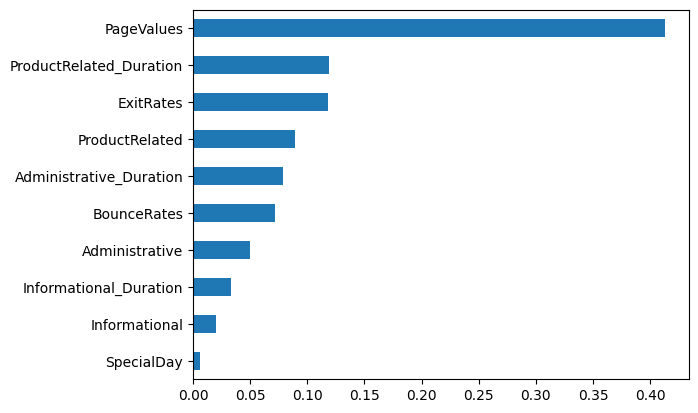

In [5]:
# [C5] ◀ 문제 4. 피처 중요도를 비즈니스 언어로 옮긴다
# ⌨️ 문제 4 — 중요도 막대 + 상위 3개의 구매율 대비

imp = pd.Series(rf.feature_importances_, index=X.columns)       
imp.sort_values().plot(kind="barh")

print(imp.sort_values(ascending=False).head(3))

print("PageValues > 0")  # 방문자가 어떤 페이지를 거친 뒤 실제로 거래를 완료했을 때, 그 매출을 해당 페이지에 나눠 배분한 평균 금액 가치
print(shoppers.groupby(shoppers["PageValues"] > 0)["Revenue"].agg(["mean", "size"]))

dur = shoppers["ProductRelated_Duration"]  # 상품 관련 페이지 총 체류 시간(초)
print("ProductRelated_Duration > median")
print(shoppers.groupby(dur > dur.median())["Revenue"].agg(["mean", "size"]))

ex = shoppers["ExitRates"]  # 평균 이탈률
print("ExitRates > median")
print(shoppers.groupby(ex > ex.median())["Revenue"].agg(["mean", "size"]))

# 모델이 예측에 활용한 상위 열은 수익 기여 페이지를 거친 방문, 상품 관련 페이지 총 체류시간, 평균 이탈률 순으로 나타남.
# PageValues(3.8->56.3%)의 경우 거래를 완료했을 때 해당 매출을 페이지에 배분한 값을 나타내는 값으로, 구매 결과가 포함된 값임.
# 구매로 이어진 행동을 추적하기 위해서는 구매가 일어나기 전에 알 수 있는 값을 찾아야 하므로 PageValues는 구매의 사전행동으로써 보기 어려움. PageValues를 제외하고 재학습하여 실제 예측력을 확인할 필요가 있음
# 한편, 체류시간이 높은 쪽에서 구매율이 증가(8.6%->22.2%)하였고, 이탈률이 높은 쪽에서는 하락(23.5%->7.4%)하였음.
# 상품 페이지 체류시간을 늘리기 위한 방안(타임세일, 추천 알고리즘 기반 상품 정렬 등)이 고려될 수 있으나, 역인과(살 마음이 있는 사람이 상품 페이지를 오래 보는 것)일 수 있으며, 본 제안은 상관관계에 근거한 가설이므로 A/B 테스트로 추가 검증이 필요함.

<details>
<summary>(클릭) 💡 힌트</summary>

- 중요도는 `rf.feature_importances_`이고, 열 이름과 묶으려면 `pd.Series(..., index=NUM_COLS)`입니다.
- 가로 막대는 `.sort_values().plot(kind="barh")` — 오름차순으로 정렬해야 1위가 맨 위에 옵니다.
- 값이 갈리는 지점은 피처마다 다릅니다. `PageValues`는 **0인지 아닌지**로 갈리고, `ExitRates`·`ProductRelated_Duration`은 중앙값(`.median()`)을 기준으로 나누면 깔끔합니다.
- 그룹별 구매율은 `shoppers.groupby(조건)["Revenue"].agg(["mean", "size"])`로 한 번에 나옵니다.

</details>

> 🎯 **[C5] 예상과 맞았나요?** 1위 `PageValues`의 중요도 **0.4130**은 2위(0.1197)의 세 배가 넘습니다. "많이 봤다"를 나타내는 `ProductRelated`(0.0893)는 4위였습니다.
>
> 더 중요한 것은 **확인한 방식**입니다. 구매율이 3.9%와 56.3%로 갈린다는 사실은 중요도가 알려준 게 아니라, 그 단서를 받고 **직접 계산해서** 알아낸 것입니다. 특히 `ExitRates`는 방향이 **반대**(값이 높을수록 구매율이 낮음)인데, 중요도 숫자만으로는 이 사실을 절대 알 수 없습니다. 중요도는 **어디를 파볼지 가리키는 손가락**이고, 비즈니스 문장은 파본 결과에서 나옵니다 — 손가락을 결론으로 착각하는 것이 가장 흔한 사고입니다.

# 문제 5. 모델 카드 v2 완성 — 오늘의 제출물

지난 순서의 모델 카드 v1에 오늘 것을 더해 **v2**로 올립니다. 굵은 항목이 오늘 새로 들어가는 부분입니다 — **4단 비교, 격차로 본 과적합 진단, 선택 근거, 피처 중요도와 그 한계.**

```
[문제 5]
1) 최종 비교표를 파일로 남기세요 — model_comparison_v2.csv
2) 아래 모델 카드 v2 템플릿의 빈칸을 여러분의 숫자와 문장으로 채우세요.
   특히 '선택한 모델과 근거'는 성능·해석력·비용 중 무엇을 우선했는지 밝혀야 합니다.
```

▶ 실행: [C6]

In [6]:
# [C6] ◀ 문제 5. 모델 카드 v2 완성 — 오늘의 제출물
# ⌨️ 문제 5 — 비교표를 파일로 남기기

final_df = pd.DataFrame(final)
final_df = final_df.sort_values("test", ascending=False)
final_df.to_csv("model_card_v2_comparison.csv", index=False)
check = pd.read_csv("model_card_v2_comparison.csv")

print(check)

          model     train      test       gap
0  RandomForest  0.999797  0.895783  0.104015
1  DecisionTree  0.904907  0.894161  0.010746
2       XGBoost  0.945053  0.887267  0.057786


**모델 카드 v2 템플릿** — 아래 빈칸을 채워 이 셀에 완성하세요 (셀을 더블클릭해 편집).

```markdown
## 모델 카드 v2 — 구매 전환 예측

- 데이터: UCI Online Shoppers (12,330 세션, 수치형 10개 열만 사용)
- 문제 유형: 분류
- **베이스라인: DummyClassifier(most_frequent) = { }**
- **비교한 모델: Dummy / 단일 트리(기본) / 단일 트리(max_depth=5) / RandomForest / XGBoost**
- 평가 지표 & 이유: { 정확도를 쓴 이유와, 그것이 왜 이 데이터에서 위험한지 }
- **성능 비교표: model_comparison_v2.csv (모델별 학습 / 테스트 / 격차)**
- 과적합 진단: { 격차가 가장 큰 모델과 그 해석 — 숫자와 함께 }
- **선택한 모델과 근거: { 무엇을 우선했나 — 성능 / 해석력 / 비용 }**
- **피처 중요도 상위 3개와 해석: { 각각 구매율 대비 숫자를 붙여 한 문장 }**
- **중요도의 한계 명시: 방향성 부재 / 개별 설명 불가 / 인과 아님**
- 한계 & 다음 단계: { 최소 두 가지 — 각각 어느 순서에서 해결되는지 }
- AI 사용 내역: { 무엇을 물었나 / 무엇을 직접 썼나 }
```

**제출:** 이 노트북(작성 셀 + 모델 카드 완성본)과 `model_comparison_v2.csv`를 개인 공개 저장소 main에 커밋·푸시하고, 저장소·커밋 링크를 제출하세요.

**스스로 점검하는 기준**

| 축 | 기준 |
| --- | --- |
| 비교의 완전성 | 베이스라인을 포함한 비교표가 있는가 |
| 진단 정확성 | 학습-테스트 격차로 과적합을 짚었는가 |
| 근거성 | 모델 선택 이유가 성능·해석력·비용 중 무엇인지 밝혔는가 |
| 정직성 | 피처 중요도의 한계를 함께 적었는가 |

> 🚀 **더 나아가기:** `max_depth=5`가 최고였던 것은 이 분할에서의 이야기입니다. `random_state`를 42가 아닌 다른 값 몇 개로 바꿔 문제 2를 다시 돌려보세요. **최고 깊이가 그대로 5일까요?** 이 실험의 결과가 다음 순서(교차 검증)를 배워야 하는 이유를 그대로 보여줍니다.

오늘 여러분은 모델 다섯 개를 **정직하게 줄 세웠습니다.** 그 과정에서 교과서와 다른 결과를 두 번 만났습니다 — 기본 트리가 베이스라인보다 못했고, 잘 조정한 한 그루가 300그루와 같았습니다. 그때 데이터를 믿고 그대로 적는 것이 분석가의 태도입니다.

오늘도 한 걸음, 수고하셨습니다! 🎉
어제의 나보다 데이터를 다루는 손이 한 뼘 더 능숙해졌습니다. 다음 시간에 또 만나요.

---

<sub>© 2026 모두의연구소(MODULABS). All rights reserved.<br>
기획·제작: 교육퍼실리테이터팀 이진영 (jy.lee@modulabs.co.kr)<br>
본 자료는 생성형 AI를 활용해 제작되었고, 제작자의 검수를 거쳐 완성되었습니다.<br>
무단 복제 및 배포를 금합니다.</sub>